## **🚀 AI-Powered Smart Loan Approval & Risk Intelligence System**

## 📌 Project Overview
This project aims to build an intelligent loan approval system using Machine Learning. The system analyzes applicant data and predicts whether a loan should be approved or rejected based on risk factors.

## 🎯 Objective
- Predict loan default risk
- Classify applicants into risk categories (Low, Medium, High)
- Assist financial institutions in making better decisions

## 🧠 Key Features
- Data preprocessing and cleaning
- Feature engineering for risk analysis
- Machine Learning model for prediction
- Risk scoring system
- Explainable AI (decision reasoning)

## 📊 Dataset
- Source: Kaggle (Home Credit Default Risk)
- Contains financial, demographic, and behavioral data

## ⚙️ Technologies Used
- Python
- Pandas, NumPy
- Scikit-learn
- Matplotlib, Seaborn

## 💡 Expected Outcome
- Accurate loan approval prediction
- Risk classification system
- Reduced default probability

## 📈 Business Impact
- Helps banks reduce loan default risk
- Improves decision-making efficiency
- Enables data-driven financial analysis

# **Step 1. Data Loading**

# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Load Dataset**

In [3]:
df = pd.read_csv('application_train.csv')
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# **Step 2. Data Preprocessing**

# **Clean Dataset**

In [4]:
selected_cols = [
    'TARGET',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_EMPLOYED',
    'DAYS_BIRTH',
    'CNT_FAM_MEMBERS',
    'CODE_GENDER',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY'
]

In [5]:
df = df[selected_cols]

# **Check Basic Info**

In [6]:
df.head()
df.shape
df.info()
df.isnull().sum().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130019 entries, 0 to 130018
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   TARGET               130019 non-null  int64  
 1   AMT_INCOME_TOTAL     130019 non-null  float64
 2   AMT_CREDIT           130019 non-null  float64
 3   AMT_ANNUITY          130011 non-null  float64
 4   AMT_GOODS_PRICE      129916 non-null  float64
 5   DAYS_EMPLOYED        130019 non-null  int64  
 6   DAYS_BIRTH           130019 non-null  int64  
 7   CNT_FAM_MEMBERS      130018 non-null  float64
 8   CODE_GENDER          130019 non-null  object 
 9   NAME_INCOME_TYPE     130019 non-null  object 
 10  NAME_EDUCATION_TYPE  130019 non-null  object 
 11  NAME_FAMILY_STATUS   130019 non-null  object 
 12  NAME_HOUSING_TYPE    130019 non-null  object 
 13  FLAG_OWN_CAR         130019 non-null  object 
 14  FLAG_OWN_REALTY      130019 non-null  object 
dtypes: float64(5), in

,0
AMT_GOODS_PRICE,103
AMT_ANNUITY,8
CNT_FAM_MEMBERS,1
AMT_CREDIT,0
AMT_INCOME_TOTAL,0
DAYS_EMPLOYED,0
TARGET,0
DAYS_BIRTH,0
CODE_GENDER,0
NAME_INCOME_TYPE,0


# **Check Dataset Balance or Not**

In [7]:
df['TARGET'].value_counts()

,count
TARGET,
0,119430
1,10589


# **Check Null or Missing Values**

In [8]:
df.isnull().sum()

,0
TARGET,0
AMT_INCOME_TOTAL,0
AMT_CREDIT,0
AMT_ANNUITY,8
AMT_GOODS_PRICE,103
DAYS_EMPLOYED,0
DAYS_BIRTH,0
CNT_FAM_MEMBERS,1
CODE_GENDER,0
NAME_INCOME_TYPE,0


# **Fill Null Values Using Median and Mode**

In [9]:
# Numerical columns fill with median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns fill with mode
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_5380/4060165332.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_5380/4060165332.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

# **Convert Object Type Data Into Number Type**

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# **Feature Scaling**

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop('TARGET', axis=1)
y = df['TARGET']

X_scaled = scaler.fit_transform(X)

# **Train-Test Split**

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# **Handle Imbalance (SMOTE)**

In [13]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [14]:
pd.Series(y_train).value_counts()
pd.Series(y_train_res).value_counts()

,count
TARGET,
0,95511
1,95511


# **Step 3. Model Training**

## **Import Models**

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# **Train Models**

In [16]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_res, y_train_res)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train_res, y_train_res)

# Gradient Boosting
gb = GradientBoostingClassifier()
gb.fit(X_train_res, y_train_res)

GradientBoostingClassifier()

# **Predictions**

In [17]:
# Predictions
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)

# **Accuracy Check**

In [18]:
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("Gradient Boosting:", accuracy_score(y_test, y_pred_gb))

Logistic Regression: 0.6076757421935087
Random Forest: 0.879710813720966
Gradient Boosting: 0.7973004153207199


# **Detailed Report**

In [19]:
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.94     23919
           1       0.15      0.11      0.13      2085

    accuracy                           0.88     26004
   macro avg       0.54      0.53      0.53     26004
weighted avg       0.86      0.88      0.87     26004



# **Feature Importance**

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = rf.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

print(importance_df)

                Feature  Importance
0      AMT_INCOME_TOTAL    0.173336
3       AMT_GOODS_PRICE    0.135292
5            DAYS_BIRTH    0.124134
1            AMT_CREDIT    0.123950
2           AMT_ANNUITY    0.121850
4         DAYS_EMPLOYED    0.102482
10   NAME_FAMILY_STATUS    0.042878
6       CNT_FAM_MEMBERS    0.039484
9   NAME_EDUCATION_TYPE    0.036023
8      NAME_INCOME_TYPE    0.028751
11    NAME_HOUSING_TYPE    0.019632
13      FLAG_OWN_REALTY    0.019039
12         FLAG_OWN_CAR    0.016961
7           CODE_GENDER    0.016189


# **Visualization**

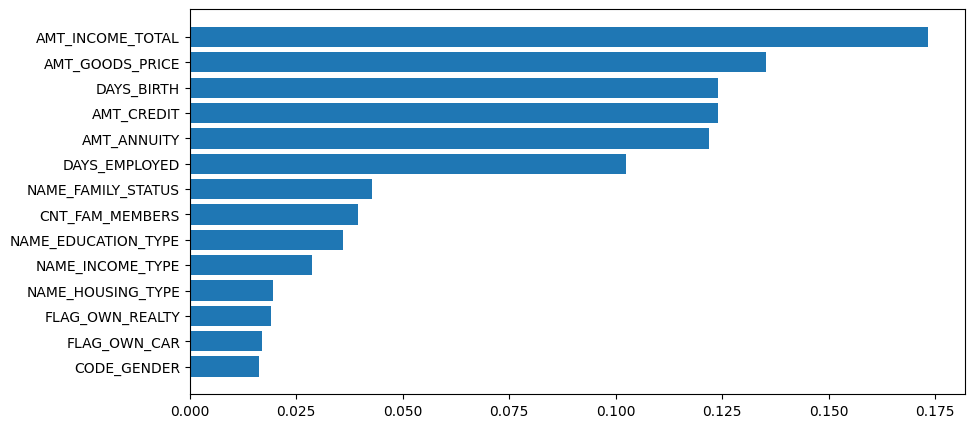

In [21]:
plt.figure(figsize=(10,5))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.show()

# **Save Model**

In [22]:
import joblib

joblib.dump(rf, 'loan_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

# **Real Prediction Function**

In [23]:
def predict_loan(data):
    data_scaled = scaler.transform([data])
    prediction = rf.predict(data_scaled)

    if prediction[0] == 1:
        return "High Risk ❌ (Loan Reject)"
    else:
        return "Low Risk ✅ (Loan Approve)"